In [1]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 (실행하면 버전과 폰트가 출력됩니다)
# ─────────────────────────────────────────────
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

# 오늘 쓰는 도구 — 전처리·조립·검증
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   OneHotEncoder, OrdinalEncoder, TargetEncoder)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

# 실습 데이터는 인터넷에서 바로 읽어옵니다 (코랩·로컬 어디서든 같은 코드로 동작)
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":                      # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True,
                       capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

print("환경 준비 완료!")
import sklearn
print(f"- scikit-learn {sklearn.__version__}")
print(f"- 그래프 한글 폰트: {plt.rcParams['font.family'][0]}")

환경 준비 완료!
- scikit-learn 1.9.0
- 그래프 한글 폰트: Malgun Gothic


In [2]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터
# 타이타닉 로드 — 수치+범주 혼합, 결측 있음 (실행하면 앞 5행과 결측 현황이 나옵니다)
# ─────────────────────────────────────────────
titanic = pd.read_csv(DATA_URL + "titanic.csv")

# 오늘 쓸 컬럼만 골라냅니다
df = titanic[["survived", "pclass", "sex", "age", "sibsp", "parch",
              "fare", "embarked", "who"]].copy()

print(f"전체 {df.shape[0]}명 × 컬럼 {df.shape[1]}개")
print(f"생존율 {df['survived'].mean():.4f}   (타깃: survived)")
print()
print(df.head(5).to_string())
print()
print("타입별 컬럼")
print(f"  수치형: {df.select_dtypes(include='number').columns.tolist()}")
print(f"  범주형: {df.select_dtypes(exclude='number').columns.tolist()}")
print()
na = df.isna().sum()
print("결측 있는 컬럼")
print(na[na > 0].to_string())
print()
print("→ age에 결측이 177건 있습니다. 이것을 어떻게 채울지도 오늘의 주제입니다.")

전체 891명 × 컬럼 9개
생존율 0.3838   (타깃: survived)

   survived  pclass     sex   age  sibsp  parch     fare embarked    who
0         0       3    male  22.0      1      0   7.2500        S    man
1         1       1  female  38.0      1      0  71.2833        C  woman
2         1       3  female  26.0      0      0   7.9250        S  woman
3         1       1  female  35.0      1      0  53.1000        S  woman
4         0       3    male  35.0      0      0   8.0500        S    man

타입별 컬럼
  수치형: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
  범주형: ['sex', 'embarked', 'who']

결측 있는 컬럼
age         177
embarked      2

→ age에 결측이 177건 있습니다. 이것을 어떻게 채울지도 오늘의 주제입니다.


In [3]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 만들고, 바꾸고, 맞춰 보기
# 파생변수 3개 생성 → 가설 검증 (실행하면 가족 크기별 생존율이 나옵니다)
# ─────────────────────────────────────────────
# pandas로 만들던 그 조작입니다
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["is_alone"] = (df["family_size"] == 1).astype(int)
df["fare_per_person"] = (df["fare"] / df["family_size"]).round(2)

print("가족 크기별 생존율")
fam = df.groupby("family_size")["survived"].agg(["mean", "size"])
fam.columns = ["생존율", "인원"]
print(fam.round(3).to_string())
print()
print(f"혼자 탄 사람({int(df['is_alone'].sum())}명) 생존율 : "
      f"{df.loc[df['is_alone'] == 1, 'survived'].mean():.3f}")
print(f"가족과 탄 사람({int((1 - df['is_alone']).sum())}명) 생존율: "
      f"{df.loc[df['is_alone'] == 0, 'survived'].mean():.3f}")

가족 크기별 생존율
               생존율   인원
family_size            
1            0.304  537
2            0.553  161
3            0.578  102
4            0.724   29
5            0.200   15
6            0.136   22
7            0.333   12
8            0.000    6
11           0.000    7

혼자 탄 사람(537명) 생존율 : 0.304
가족과 탄 사람(354명) 생존율: 0.506


In [4]:
# ─────────────────────────────────────────────
# [C4] Part 1 · 📊 데이터로 확인해 봅시다 — 만들고, 바꾸고, 맞춰 보기
# One-Hot vs Ordinal — embarked를 두 방식으로 인코딩해 비교 (실행하면 CV 점수가 나옵니다)
# ─────────────────────────────────────────────
y = df["survived"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base_num = ["pclass", "age", "fare"]      # 효과를 보려고 일부러 최소 구성으로

encoders = [
    ("One-Hot", OneHotEncoder(handle_unknown="ignore")),
    ("Ordinal(Label)", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
]

for label, enc in encoders:
    pre = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), base_num),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", enc)]), ["embarked"]),
    ])
    pipe = Pipeline([("pre", pre),
                     ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
    s = cross_val_score(pipe, df[base_num + ["embarked"]], y, cv=cv, scoring="accuracy")
    print(f"  {label:16} CV 정확도 {s.mean():.4f} ± {s.std():.4f}")

print()
print(f"embarked의 범주: {sorted(df['embarked'].dropna().unique().tolist())} ({df['embarked'].nunique()}개)")

  One-Hot          CV 정확도 0.7003 ± 0.0231
  Ordinal(Label)   CV 정확도 0.7104 ± 0.0333

embarked의 범주: ['C', 'Q', 'S'] (3개)


In [7]:
# ─────────────────────────────────────────────
# [C5] Part 1 · 📊 데이터로 확인해 봅시다 — 만들고, 바꾸고, 맞춰 보기
# 스케일링이 거리 기반 모델(KNN)에 미치는 영향 (실행하면 스케일러별 점수가 나옵니다)
# ─────────────────────────────────────────────
NUM_COLS = ["pclass", "age", "sibsp", "parch", "fare",
            "family_size", "is_alone", "fare_per_person"]

print("컬럼별 값의 범위 (스케일 차이 확인)")
rng = df[NUM_COLS].agg(["min", "max"]).T
rng["범위"] = rng["max"] - rng["min"]
print(rng.round(1).to_string())
print()

print("KNN(n_neighbors=5) 성능 — 스케일러별")
scalers = [(None, "스케일링 없음"), (StandardScaler(), "StandardScaler"),
           (MinMaxScaler(), "MinMaxScaler"), (RobustScaler(), "RobustScaler")]
for sc, label in scalers:
    steps = [("impute", SimpleImputer(strategy="median"))]
    if sc is not None:
        steps.append(("scale", sc))
    steps.append(("clf", KNeighborsClassifier(n_neighbors=5)))
    s = cross_val_score(Pipeline(steps), df[NUM_COLS], y, cv=cv, scoring="accuracy")
    print(f"  {label:16} {s.mean():.4f} ± {s.std():.4f}")

print()
print("fare = 지불액")  

컬럼별 값의 범위 (스케일 차이 확인)
                 min    max     범위
pclass           1.0    3.0    2.0
age              0.4   80.0   79.6
sibsp            0.0    8.0    8.0
parch            0.0    6.0    6.0
fare             0.0  512.3  512.3
family_size      1.0   11.0   10.0
is_alone         0.0    1.0    1.0
fare_per_person  0.0  512.3  512.3

KNN(n_neighbors=5) 성능 — 스케일러별
  스케일링 없음          0.6958 ± 0.0180
  StandardScaler   0.7059 ± 0.0335
  MinMaxScaler     0.7014 ± 0.0336
  RobustScaler     0.7104 ± 0.0226

fare = 지불액


[문제]
파생변수를 하나 더 만들어 가설을 검증합니다.

1) age를 구간으로 나눈 age_group을 만듭니다.
   구간: 0~12(child) / 13~19(teen) / 20~59(adult) / 60~(senior)
   힌트: pd.cut()을 쓰면 한 줄입니다. 결측은 그대로 둡니다.
2) age_group별 생존율과 인원을 출력합니다.
3) 이 파생변수가 '좋은 피처의 조건' 세 가지를 만족하는지 판단합니다.

In [13]:
# [C6] Part 1 · ⌨️ 백문이 불여일타! (1)
# ⌨️ 백문이 불여일타! (1) — age를 구간화해 새 피처 만들고 가설 검증

bins = [0, 12, 19, 59, 200]
labels = ["child", "teen", "adult", "senior"]

# 여기에 코드를 작성하세요

df["age_group"]=pd.cut(df["age"], bins=bins, labels=labels)
print("age_group별 생존율과 인원")
df.groupby("age_group")["survived"].agg(["mean", "size"])

# '좋은 피처의 조건' 업무 가설이 분명한가 / 예측 시점에 사용 가능한가 / 추가 효과가 검증되는가
# 다 만족하는 듯 / 구간 별 fare(지불액)과 승객 등급 비율을 알 수 있음.


age_group별 생존율과 인원


,mean,size
age_group,,
child,0.579710,69
teen,0.410526,95
adult,0.389313,524
senior,0.269231,26


In [14]:
# ─────────────────────────────────────────────
# [C7] Part 2 · 📊 데이터로 확인해 봅시다 — 검증 누수를 재현하기
# (나쁜 방법) 테스트로 고르기 vs (옳은 방법) CV로 고르기 (실행하면 두 결론이 비교됩니다)
# ─────────────────────────────────────────────
FEAT_NUM = NUM_COLS                       # [C5]에서 정한 수치형 8개
FEAT_CAT = ["sex", "embarked", "who"]
X = df[FEAT_NUM + FEAT_CAT]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)


def make_pre():
    """수치·범주 분기 전처리를 새로 만들어 돌려줍니다."""
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), FEAT_NUM),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore"))]), FEAT_CAT),
    ])


rows = []
for depth in [2, 3, 4, 5, 7, 10, None]:
    pipe = Pipeline([("pre", make_pre()),
                     ("clf", DecisionTreeClassifier(max_depth=depth,
                                                    random_state=RANDOM_STATE))])
    cv_score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy").mean()
    pipe.fit(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    rows.append({"max_depth": "제한 없음" if depth is None else depth,
                 "학습셋 CV": cv_score, "테스트": test_score})

sel = pd.DataFrame(rows)
print(sel.round(4).to_string(index=False))
print()
bad = sel.loc[sel["테스트"].idxmax()]
good = sel.loc[sel["학습셋 CV"].idxmax()]
print(f"✗ 나쁜 방법 — 테스트로 고름: max_depth={bad['max_depth']} → 보고 점수 {bad['테스트']:.4f}")
print(f"✓ 옳은 방법 — CV로 고름:    max_depth={good['max_depth']} → 테스트 점수 {good['테스트']:.4f}")
print(f"→ 부풀림 {bad['테스트'] - good['테스트']:+.4f}")

max_depth  학습셋 CV    테스트
        2  0.7949 0.7937
        3  0.8113 0.8072
        4  0.8053 0.8161
        5  0.8158 0.7623
        7  0.8069 0.7578
       10  0.7814 0.7489
    제한 없음  0.7620 0.7265

✗ 나쁜 방법 — 테스트로 고름: max_depth=4 → 보고 점수 0.8161
✓ 옳은 방법 — CV로 고름:    max_depth=5 → 테스트 점수 0.7623
→ 부풀림 +0.0538


.fit <- train 데이터 셋(학습데이터 적합이니까)
.score <- test 데이터 셋(검증데이터랑 비교니까)

[문제]
아래는 동료가 짠 코드입니다. 누수가 몇 개 있는지 찾습니다.

  # 1) 전체 데이터로 결측을 채운다
  X_filled = X.copy()
  X_filled["age"] = X_filled["age"].fillna(X_filled["age"].median())

  # 2) 전체 데이터로 스케일링한다
  X_scaled = StandardScaler().fit_transform(X_filled[FEAT_NUM])

  # 3) 나눠서 학습한다
  Xa, Xb, ya, yb = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
  model = DecisionTreeClassifier(max_depth=4).fit(Xa, ya)
  print("테스트 정확도:", model.score(Xb, yb))

1) 누수가 발생한 줄 번호와, 각각 무엇이 새는지 적습니다.
2) 이 코드의 "테스트 정확도"를 신뢰할 수 있습니까? 이유와 함께 적습니다.
3) 유형 ①~④ 중 이 코드에 해당하는 것은 무엇입니까?

(1) 무엇이 새는가
결측치를 전체 데이터로 채움 / 스케일링을 전체 데이터로 함

(2 ) 이 코드의 "테스트 정확도"를 신뢰할 수 없음. 
ㄴ 테스트셋의 age 값이 결측치 채움에 영향을 줬기에 신뢰 불가
ㄴ 스케일링의 평균과 표준편차에도 테스트셋의 분포 정보가 들어있기에 테스트 정확도 신뢰 x

(3) 유형 ① 전처리

In [15]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — 묶고, 새는지 재보기
# 기본 Pipeline 만들기 → 내부 단계 확인 (실행하면 단계 목록과 학습된 기준값이 나옵니다)
# ─────────────────────────────────────────────
simple = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

simple.fit(X_train[FEAT_NUM], y_train)    #.fit

print("Pipeline 단계 목록")
for name, step in simple..items()named_steps:
    print(f"  {name:8} {type(step).__name__}")
print()
print("named_steps로 내부에 접근할 수 있습니다")
med = simple.named_steps["impute"].statistics_     #.named_steps
print(f"  대치에 쓴 중앙값 (앞 3개): {med[:3].round(2)}")
print(f"  → age 중앙값 {med[FEAT_NUM.index('age')]:.1f}  (학습 조각에서만 계산된 값)")
print()
print(f"테스트 정확도: {simple.score(X_test[FEAT_NUM], y_test):.4f}")  #.predict
print()
print("→ predict할 때 전처리는 fit을 다시 하지 않고, 학습 때의 기준값을 '적용만' 합니다.")

Pipeline 단계 목록
  impute   SimpleImputer
  scale    StandardScaler
  clf      LogisticRegression

named_steps로 내부에 접근할 수 있습니다
  대치에 쓴 중앙값 (앞 3개): [ 3. 29.  0.]
  → age 중앙값 29.0  (학습 조각에서만 계산된 값)

테스트 정확도: 0.6816

→ predict할 때 전처리는 fit을 다시 하지 않고, 학습 때의 기준값을 '적용만' 합니다.


🎯 [C9] 확인하기
.fit() 한 번에 내부 세 단계가 순서대로 적합됩니다 — 대치용 중앙값 계산, 표준화용 평균·표준편차 계산, 그리고 모델 학습입니다.

그리고 .predict()에서는 전처리가 fit을 다시 하지 않습니다. transform만 합니다. 학습 때 계산한 중앙값을 테스트 데이터에 적용만 하는 것입니다. **이것이 누수를 막는 메커니즘의 핵심입니다.**

named_steps로 내부를 꺼내 볼 수 있다는 것도 기억합니다. 디버깅할 때, 그리고 나중에 SHAP으로 해석할 때 씁니다.

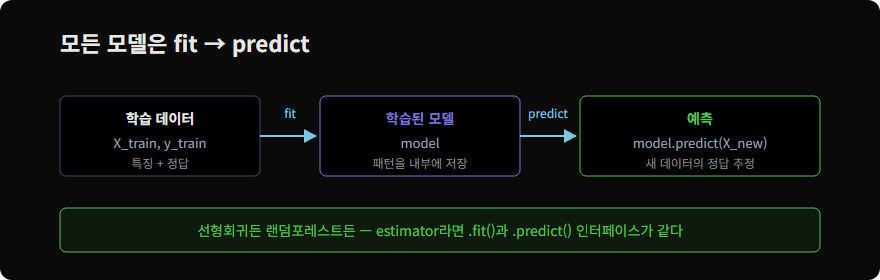

In [16]:
# ─────────────────────────────────────────────
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — 묶고, 새는지 재보기
# ColumnTransformer로 수치·범주 분기 → 두 겹 Pipeline 완성 (실행하면 변환 후 피처명이 나옵니다)
# ─────────────────────────────────────────────
model = Pipeline([("pre", make_pre()),
                  ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
model.fit(X_train, y_train) #.fit

names = model.named_steps["pre"].get_feature_names_out()
print(f"입력 컬럼 {X_train.shape[1]}개 → 변환 후 피처 {len(names)}개")
print()
print("변환 후 피처 이름")
for n in names:
    print(f"  {n}")
print()
print(f"테스트 정확도: {model.score(X_test, y_test):.4f}")  #.predict
print()
print("→ 'num__'·'cat__' 접두사로 어느 갈래에서 왔는지 알 수 있습니다.")
print("  범주형 3개가 One-Hot으로 펼쳐져 열이 늘어났습니다.")

입력 컬럼 11개 → 변환 후 피처 16개

변환 후 피처 이름
  num__pclass
  num__age
  num__sibsp
  num__parch
  num__fare
  num__family_size
  num__is_alone
  num__fare_per_person
  cat__sex_female
  cat__sex_male
  cat__embarked_C
  cat__embarked_Q
  cat__embarked_S
  cat__who_child
  cat__who_man
  cat__who_woman

테스트 정확도: 0.8161

→ 'num__'·'cat__' 접두사로 어느 갈래에서 왔는지 알 수 있습니다.
  범주형 3개가 One-Hot으로 펼쳐져 열이 늘어났습니다.


👀 [C10] 결과읽기
입력 11개 컬럼이 변환 후 더 많은 피처가 됐습니다. sex(2) + embarked(3) + who(3)가 One-Hot으로 펼쳐진 결과입니다.

피처 이름에 붙은 num__·cat__ 접두사가 어느 갈래에서 왔는지 알려줍니다. 이 이름이 있어야 나중에 "어떤 피처가 중요했나"를 사람이 읽을 수 있습니다.

이제 오늘의 핵심 실험입니다. 누수 버전과 Pipeline 버전의 점수를 직접 비교합니다.

동료가 이런 피처를 만들었다고 해봅시다 — "운임과 등급 조합별 과거 생존율". 실무에서는 "고객 세그먼트별 과거 이탈률", "지역별 부도율" 같은 형태로 아주 흔하게 등장하는 피처입니다. 좋은 아이디어처럼 보입니다.

In [19]:
# ─────────────────────────────────────────────
# [C11] Part 3 · 📊 데이터로 확인해 봅시다 — 묶고, 새는지 재보기
# 타깃 누수 재현 — "세그먼트별 과거 생존율" 피처 (실행하면 부풀림 크기가 나옵니다)
# ─────────────────────────────────────────────
# 동료가 만든 세그먼트 키 (운임 + 등급 조합)

print("운임과 등급 조합별 과거 생존율")
seg = df["fare"].round(2).astype(str) + "_" + df["pclass"].astype(str)
print(f"세그먼트 키의 고유값: {seg.nunique()}개 / 전체 {len(seg)}명")
print(f"  → 세그먼트 하나에 평균 {len(seg) / seg.nunique():.1f}명뿐입니다. 이것이 문제의 씨앗입니다.")
print()

# ✗ 누수 버전 — 전체 데이터의 타깃으로 세그먼트별 생존율을 계산해 피처로 씀
seg_rate = y.groupby(seg).mean()            # 전체 y를 봤다!
df_leak = df.copy()
df_leak["seg_survival_rate"] = seg.map(seg_rate)

LEAK_NUM = FEAT_NUM + ["seg_survival_rate"]
pre_leak = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), LEAK_NUM),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), FEAT_CAT),
])
leaky = cross_val_score(
    Pipeline([("pre", pre_leak), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    df_leak[LEAK_NUM + FEAT_CAT], y, cv=cv, scoring="accuracy")

# ✓ Pipeline 버전 — 같은 아이디어를 TargetEncoder로, Pipeline 안에서 (조각별로 따로 계산)
df_ok = df.copy()
df_ok["segment"] = seg
pre_ok = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), FEAT_NUM),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), FEAT_CAT),
    ("seg", TargetEncoder(random_state=RANDOM_STATE), ["segment"]),  # 내부 교차 적합
])
clean = cross_val_score(
    Pipeline([("pre", pre_ok), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    df_ok[FEAT_NUM + FEAT_CAT + ["segment"]], y, cv=cv, scoring="accuracy")

print(f"✗ 누수 버전 (전체 y로 생존율 계산)  CV {leaky.mean():.4f} ± {leaky.std():.4f}")
print(f"✓ Pipeline 버전 (조각별로 따로 계산) CV {clean.mean():.4f} ± {clean.std():.4f}")
print()
print(f"→ 부풀림 {leaky.mean() - clean.mean():+.4f}")
print(f"  누수 버전의 표준편차({leaky.std():.4f})가 유난히 작은 것도 누수 신호입니다.")

운임과 등급 조합별 과거 생존율
세그먼트 키의 고유값: 243개 / 전체 891명
  → 세그먼트 하나에 평균 3.7명뿐입니다. 이것이 문제의 씨앗입니다.

✗ 누수 버전 (전체 y로 생존율 계산)  CV 0.8945 ± 0.0074
✓ Pipeline 버전 (조각별로 따로 계산) CV 0.8350 ± 0.0165

→ 부풀림 +0.0595
  누수 버전의 표준편차(0.0074)가 유난히 작은 것도 누수 신호입니다.


세그먼트 키의 고유값이 243개인데 전체가 891명입니다. 
세그먼트 하나에 평균 3.7명뿐입니다. 그러면 "이 세그먼트의 생존율"은 사실상 그 3~4명의 정답 평균이고, 각 사람의 피처에 자기 자신의 정답이 들어갑니다.

모델은 이것을 놓치지 않습니다. seg_survival_rate만 보면 정답을 거의 알 수 있으니, 0.8945라는 훌륭한 점수가 나옵니다. 그리고 이 점수는 검증 행의 타깃이 피처 계산에 참여해 낙관적으로 편향되었습니다. 운영 데이터에서는 같은 방식으로 미래 타깃을 사용할 수 없으므로 개발 점수가 재현되지 않을 수 있습니다. 

TargetEncoder를 Pipeline 안에 넣으면 바깥쪽 교차 검증의 각 학습 조각에서 fit_transform이 내부 교차 적합을 수행합니다. 검증 조각에는 학습 조각에서 얻은 인코딩만 적용되어 0.8350을 냅니다. 이 값이 정직한 추정입니다.

In [20]:
# ─────────────────────────────────────────────
# [C12] Part 3 · 📊 데이터로 확인해 봅시다 — 묶고, 새는지 재보기
# 전처리 누수(유형 ①)는 얼마나 부풀리나 — 정직한 재검증 (실행하면 차이가 나옵니다)
# ─────────────────────────────────────────────
# ✗ 누수 버전 — 대치와 표준화를 전체 데이터로 먼저
X_leaked = make_pre().fit_transform(X)      # 전체 X로 fit (검증 조각 포함)
leak_pre = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    X_leaked, y, cv=cv, scoring="accuracy")

# ✓ Pipeline 버전
clean_pre = cross_val_score(
    Pipeline([("pre", make_pre()),
              ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    X, y, cv=cv, scoring="accuracy")

print("누수 유형별 부풀림 크기 비교")
print(f"  유형 ② 타깃 누수   : {leaky.mean() - clean.mean():+.4f}   ([C11] 결과)")
print(f"  유형 ① 전처리 누수 : {leak_pre.mean() - clean_pre.mean():+.4f}")
print()
print(f"    누수 버전   CV {leak_pre.mean():.4f} ± {leak_pre.std():.4f}")
print(f"    Pipeline    CV {clean_pre.mean():.4f} ± {clean_pre.std():.4f}")
print()
print("→ 전처리 누수는 이 데이터에서 거의 부풀리지 않았습니다. 그래도 원칙은 같습니다.")

누수 유형별 부풀림 크기 비교
  유형 ② 타깃 누수   : +0.0595   ([C11] 결과)
  유형 ① 전처리 누수 : +0.0000

    누수 버전   CV 0.8204 ± 0.0080
    Pipeline    CV 0.8204 ± 0.0080

→ 전처리 누수는 이 데이터에서 거의 부풀리지 않았습니다. 그래도 원칙은 같습니다.


같은 '누수'인데 한쪽은 6%p, 한쪽은 0입니다. 왜일까요?

전처리 누수가 새는 것은 "분포 통계량"뿐입니다. 891행에서 전체의 중앙값과 학습 조각(713행)의 중앙값은 거의 같습니다. 새는 정보의 양이 미미합니다.

타깃 누수가 새는 것은 "정답 그 자체" 입니다. 양이 아니라 종류가 다릅니다.

그러면 전처리 누수는 신경 쓰지 않아도 될까요? 아닙니다. 세 가지 이유가 있습니다.

▸
표본이 적으면 벌어집니다. 891행이라 통계량이 안정적이었을 뿐입니다
▸
강한 변환일수록 벌어집니다. 전체 데이터로 수행한 피처 선택·차원 축소는 더 큰 편향을 만들 수 있습니다. 타깃 인코딩은 별도의 타깃 누수 위험이며 [C11]이 그 예입니다
▸
Pipeline은 전처리 순서와 적용 범위를 한 객체에 기록해 코드 중복과 운영 불일치도 줄입니다

[문제]
Part 2의 ⌨️(2)에서 본 동료의 누수 코드를, 이제 Pipeline으로 고칩니다.

1) 결측 대치(중앙값) → 표준화 → DecisionTreeClassifier(max_depth=4)를
   하나의 Pipeline으로 만듭니다. (수치형 FEAT_NUM만 사용)
2) 그 Pipeline으로 계층 5겹 교차 검증 점수를 구합니다.
3) named_steps로 대치에 쓴 age 중앙값을 꺼내 출력합니다.
   전체 데이터의 age 중앙값과 비교하면 어떻습니까? 똑같은디

In [31]:
# [C13] Part 3 · ⌨️ 백문이 불여일타! (3)
# ⌨️ 백문이 불여일타! (3) — 누수 코드를 Pipeline으로 고치기

# 여기에 코드를 작성하세요

simple = Pipeline([
    ("impute", SimpleImputer(strategy="median")),  #결측 대치(중앙값)
    ("scale", StandardScaler()),                   #표준화 
    ("clf", DecisionTreeClassifier(max_depth=4)),
])

# pre_ok = ColumnTransformer([
#   ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
#                     ("scale", StandardScaler())]), FEAT_NUM),
# ])

clean = cross_val_score(
    simple,
    df_ok[FEAT_NUM], y, cv=cv, scoring="accuracy")

print(f" CV 정확도 {clean.mean():.4f} ± {clean.std():.4f}")

simple.fit(df_ok[FEAT_NUM], y) 
med = simple.named_steps["impute"].statistics_   
print(f"  → age 중앙값 {med[FEAT_NUM.index('age')]:.1f}  (학습 조각에서만 계산된 값)")
print()
print(f" 전체 데이터의 age 중앙값 {df["age"].median():.3f}")

 CV 정확도 0.7026 ± 0.0224
  → age 중앙값 28.0  (학습 조각에서만 계산된 값)

 전체 데이터의 age 중앙값 28.000


In [32]:
# ─────────────────────────────────────────────
# [C14] Part 4 · 📊 데이터로 확인해 봅시다 — 파이프 안에서 실험하기
# Pipeline 통째로 GridSearchCV — 전처리 옵션까지 함께 (실행하면 best와 변화량이 나옵니다)
# ─────────────────────────────────────────────
pipe_tune = Pipeline([("pre", make_pre()),
                      ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

grid = {
    "clf__C": [0.01, 0.1, 1, 10],                        # 모델 파라미터
    "pre__num__impute__strategy": ["median", "mean"],    # 전처리 옵션까지 튜닝
}

gs = GridSearchCV(pipe_tune, grid, cv=cv, scoring="accuracy", n_jobs=-1)
gs.fit(X, y)

n_comb = len(grid["clf__C"]) * len(grid["pre__num__impute__strategy"])
print(f"탐색 공간: {n_comb}조합 × 5겹 = {n_comb * 5}회 학습")
print(f"파라미터 이름 규칙: 단계명__파라미터명 (중첩은 __로 이어 붙임)")
print()
print(f"best 조합: {gs.best_params_}")
print(f"best CV : {gs.best_score_:.4f}")

base = cross_val_score(pipe_tune, X, y, cv=cv, scoring="accuracy")
print()
print(f"기본값 CV {base.mean():.4f} → 튜닝 후 {gs.best_score_:.4f}   변화 {gs.best_score_ - base.mean():+.4f}")

탐색 공간: 8조합 × 5겹 = 40회 학습
파라미터 이름 규칙: 단계명__파라미터명 (중첩은 __로 이어 붙임)

best 조합: {'clf__C': 10, 'pre__num__impute__strategy': 'mean'}
best CV : 0.8227

기본값 CV 0.8204 → 튜닝 후 0.8227   변화 +0.0022


best 조합은 {"clf__C": 10, "pre__num__impute__strategy": "mean"} — 둘 다 기본값이 아닙니다(기본은 C=1·median). 

문제는 그 이득의 크기입니다. 0.0022는 이 5겹 CV에서 관찰된 겹별 변동보다 작습니다. 겹별 표준편차와 평균 차이를 직접 비교해 통계적 유의성을 판정할 수는 없지만, 이 결과만으로 실질적 개선을 주장하기에는 근거가 부족합니다. 실험 기록표에는 이렇게 적습니다 — "로지스틱 C·대치 전략 8조합 탐색. best는 기본값과 달랐으나 이득 +0.002로 표준편차 미만. 채택 여부 무의미." 이 기록이 있으면 다음 사람이 같은 40회를 다시 돌리지 않습니다.

파라미터 이름 규칙도 확인합니다. pre__num__impute__strategy — 전처리 옵션이 튜닝 대상이 됐습니다. 전처리를 Pipeline 밖에서 했다면 이 실험은 애초에 불가능했습니다.

In [33]:
# ─────────────────────────────────────────────
# [C15] Part 4 · 📊 데이터로 확인해 봅시다 — 파이프 안에서 실험하기
# 레버별 효과 비교 — 피처 vs 모델 vs 튜닝 (실행하면 각 레버의 순증이 나옵니다)
# ─────────────────────────────────────────────
def cv_of(num_cols, cat_cols, clf):
    """주어진 피처 구성과 모델의 계층 5겹 CV 정확도를 돌려줍니다."""
    pre = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), num_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ])
    return cross_val_score(Pipeline([("pre", pre), ("clf", clf)]),
                           df[num_cols + cat_cols], y, cv=cv, scoring="accuracy").mean()


LR = lambda: LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
RAW = ["pclass", "age", "sibsp", "parch", "fare"]
DERIVED = RAW + ["family_size", "is_alone", "fare_per_person"]

s1 = cv_of(RAW, ["embarked"], LR())                          # 최소 구성
s2 = cv_of(RAW, ["embarked", "sex"], LR())                   # 강한 원본 피처 추가
s3 = cv_of(DERIVED, ["embarked", "sex"], LR())               # 파생 3개 추가
s4 = cv_of(DERIVED, ["embarked", "sex", "who"], LR())        # 도메인 피처 추가
s5 = cv_of(DERIVED, ["embarked", "sex", "who"],
           RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))  # 모델 교체

gs_rf = GridSearchCV(
    Pipeline([("pre", make_pre()), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
    {"clf__n_estimators": [200, 400], "clf__min_samples_leaf": [1, 3, 5],
     "clf__max_depth": [None, 8]},
    cv=cv, scoring="accuracy", n_jobs=-1).fit(X, y)
s6 = gs_rf.best_score_                                        # 튜닝

steps = [("① 수치 5개 + embarked", s1, None),
         ("② + sex", s2, s2 - s1),
         ("③ + 파생 3개", s3, s3 - s2),
         ("④ + who", s4, s4 - s3),
         ("⑤ 모델 교체 → RandomForest", s5, s5 - s4),
         ("⑥ 튜닝 (RF 12조합)", s6, s6 - s5)]
for label, val, delta in steps:
    d = f"   ({delta:+.4f})" if delta is not None else ""
    print(f"  {label:30} {val:.4f}{d}")

print()
print(f"  피처 레버 ①→④   {s4 - s1:+.4f}   ← 데이터·피처")
print(f"  모델 레버 ④→⑤   {s5 - s4:+.4f}")
print(f"  튜닝 레버 ⑤→⑥   {s6 - s5:+.4f}")
print(f"\n  RF best: {gs_rf.best_params_}")

  ① 수치 5개 + embarked             0.7026
  ② + sex                        0.7935   (+0.0909)
  ③ + 파생 3개                      0.8014   (+0.0079)
  ④ + who                        0.8204   (+0.0191)
  ⑤ 모델 교체 → RandomForest         0.8170   (-0.0034)
  ⑥ 튜닝 (RF 12조합)                 0.8395   (+0.0225)

  피처 레버 ①→④   +0.1178   ← 데이터·피처
  모델 레버 ④→⑤   -0.0034
  튜닝 레버 ⑤→⑥   +0.0225

  RF best: {'clf__max_depth': 8, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}


In [34]:
# ─────────────────────────────────────────────
# [C16] Part 4 · 📊 데이터로 확인해 봅시다 — 파이프 안에서 실험하기
# 실험 기록표 — 조건 → 지표 → 결정 (실행하면 오늘의 실험 이력이 표로 나옵니다)
# ─────────────────────────────────────────────
experiments = pd.DataFrame([
    {"조건": "수치 5 + embarked (최소)", "CV 정확도": s1,
     "결정": "기준선으로 채택"},
    {"조건": "+ sex", "CV 정확도": s2,
     "결정": "★채택 — 단일 피처 최대 효과 (+0.091)"},
    {"조건": "+ 파생 3개(family_size·is_alone·fare_per_person)", "CV 정확도": s3,
     "결정": "채택 — 효과는 작지만(+0.008) 해석에 도움"},
    {"조건": "+ who", "CV 정확도": s4,
     "결정": "★채택 (+0.019)"},
    {"조건": "모델 교체 → RandomForest", "CV 정확도": s5,
     "결정": "기각 — 오히려 하락(-0.003). 단, 튜닝 여지 확인 위해 ⑥ 진행"},
    {"조건": "RandomForest 튜닝 12조합", "CV 정확도": s6,
     "결정": "★최종 채택 (+0.023)"},
    {"조건": "로지스틱 C·대치전략 8조합 튜닝", "CV 정확도": gs.best_score_,
     "결정": "기각 — 이득 +0.002로 표준편차 미만"},
])
print("실험 기록표 — 조건 → 지표 → 결정")
print()
print(experiments.round(4).to_string(index=False))
print()
print("→ '결정' 열이 핵심입니다. 기각한 실험도 지우지 않고 남깁니다.")
print("  다음 사람이 같은 실패를 반복하지 않게 하는 것이 기록의 목적입니다.")

실험 기록표 — 조건 → 지표 → 결정

                                           조건  CV 정확도                                       결정
                         수치 5 + embarked (최소)  0.7026                                 기준선으로 채택
                                        + sex  0.7935               ★채택 — 단일 피처 최대 효과 (+0.091)
+ 파생 3개(family_size·is_alone·fare_per_person)  0.8014              채택 — 효과는 작지만(+0.008) 해석에 도움
                                        + who  0.8204                             ★채택 (+0.019)
                         모델 교체 → RandomForest  0.8170 기각 — 오히려 하락(-0.003). 단, 튜닝 여지 확인 위해 ⑥ 진행
                         RandomForest 튜닝 12조합  0.8395                          ★최종 채택 (+0.023)
                           로지스틱 C·대치전략 8조합 튜닝  0.8227                  기각 — 이득 +0.002로 표준편차 미만

→ '결정' 열이 핵심입니다. 기각한 실험도 지우지 않고 남깁니다.
  다음 사람이 같은 실패를 반복하지 않게 하는 것이 기록의 목적입니다.


In [35]:
# ─────────────────────────────────────────────
# [C17] Part 4 · 📊 데이터로 확인해 봅시다 — 파이프 안에서 실험하기
# joblib 저장 → 재로드 → 예측 일치 확인 (실행하면 일치 여부와 파일 크기가 나옵니다)
# ─────────────────────────────────────────────
import os

best_model = gs_rf.best_estimator_
MODEL_PATH = "titanic_pipeline.joblib"

joblib.dump(best_model, MODEL_PATH)
loaded = joblib.load(MODEL_PATH)

pred_before = best_model.predict(X)
pred_after = loaded.predict(X)
same = np.array_equal(pred_before, pred_after)

print(f"저장 파일: {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1024 / 1024:.2f} MB)")
print(f"재로드 후 예측이 원본과 동일: {same}")
print()
print("저장된 Pipeline이 품고 있는 것")
inner_pre = loaded.named_steps["pre"]
print(f"  1. 전처리 — 결측 대치 기준값, 표준화 기준, One-Hot 범주 목록")
print(f"     변환 후 피처 {len(inner_pre.get_feature_names_out())}개")
print(f"  2. 모델   — RandomForest {loaded.named_steps['clf'].n_estimators}그루")
print()
print("→ 전처리 기준까지 함께 저장되므로 새 데이터에 '학습 때와 똑같은 변환'이 적용됩니다.")
print("  전처리 코드를 따로 관리하면 이 일관성이 언젠가 반드시 깨집니다.")

저장 파일: titanic_pipeline.joblib (1.38 MB)
재로드 후 예측이 원본과 동일: True

저장된 Pipeline이 품고 있는 것
  1. 전처리 — 결측 대치 기준값, 표준화 기준, One-Hot 범주 목록
     변환 후 피처 16개
  2. 모델   — RandomForest 200그루

→ 전처리 기준까지 함께 저장되므로 새 데이터에 '학습 때와 똑같은 변환'이 적용됩니다.
  전처리 코드를 따로 관리하면 이 일관성이 언젠가 반드시 깨집니다.


[문제]
실험을 하나 더 설계해 기록표에 추가합니다.

1) [C15]의 cv_of 함수를 써서, 파생변수를 하나씩만 넣었을 때의 효과를 각각 측정합니다.
   (family_size만 / is_alone만 / fare_per_person만)
   기준은 ② 구성(RAW + embarked + sex)입니다.
2) 세 파생변수 중 어느 것이 단독으로 가장 효과가 컸습니까?
3) 세 효과를 각각 더한 값과 [C15]의 ③ 순증(+0.0079)을 비교합니다.
   같습니까? 다르다면 왜 그럴까요?

In [45]:
# [C18] Part 4 · ⌨️ 백문이 불여일타! (4)
# ⌨️ 백문이 불여일타! (4) — 파생변수를 하나씩 넣어 개별 효과 재기

derived_cols = ["family_size", "is_alone", "fare_per_person"]

# 여기에 코드를 작성하세요


s2 = cv_of(RAW, ["embarked", "sex"], LR())                              # 기준
s6 = cv_of(RAW + ["family_size"],      ["embarked", "sex"], LR())        # family_size만
s7 = cv_of(RAW + ["is_alone"],         ["embarked", "sex"], LR())        # is_alone만
s8 = cv_of(RAW + ["fare_per_person"],  ["embarked", "sex"], LR())  

print(f"기준(②)          : {s2:.4f}")
print(f"+ family_size     : {s6:.4f}   ({s6-s2:+.4f})")
print(f"+ is_alone        : {s7:.4f}   ({s7-s2:+.4f})")
print(f"+ fare_per_person : {s8:.4f}   ({s8-s2:+.4f})")



print()
print(f"세 효과의 합: {(s6-s2)+(s7-s2)+(s8-s2):+.4f}")

기준(②)          : 0.7935
+ family_size     : 0.7935   (+0.0000)
+ is_alone        : 0.8014   (+0.0079)
+ fare_per_person : 0.7935   (-0.0000)

세 효과의 합: +0.0079


피처들이 서로 정보를 공유하면 효과가 단순히 더해지지 않는다
그러나 정보가 독립적이면(independent) → 합 ≈ 실제 순증

[문제]
빈칸(____)을 채워, Pipeline을 통째로 GridSearchCV에 넣어
DecisionTree의 max_depth와 전처리 대치 전략을 함께 튜닝합니다.

In [ ]:
# [C19] ❓ 오늘의 퀴즈 · 코드 퀴즈
# 코드 퀴즈 — 빈칸(____)을 채워 Pipeline 통째 튜닝

quiz_pipe = Pipeline([("pre", make_pre()),
                      ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])
# quiz_grid = {
#     "clf__C": [3, 4, 5, 6],                       # clf 단계의 max_depth
#     "pre__num__impute_strategy": ["median", "mean"], # 대치 전략
# }
# quiz_gs = GridSearchCV(quiz_pipe, quiz_grid, cv=cv, scoring="accuracy").fit(X, y)
# print("best:", quiz_gs.best_score_, "→ CV", round(quiz_gs.to_string, 4))

# 여기에 코드를 작성하세요